- MSSV: 25410291
- Họ Tên: Đinh Xuân Sâm
- GDrive: [IE313 > notebooks](https://drive.google.com/drive/folders/1nap2ahjmAj6aj1cm6xr5nZDrBFeBjc00)
- Github: [sam-uit/IE313](https://github.com/sam-uit/IE313)


# Buổi 09 - Bài 07 - Đánh Giá Mô Hình - Bài Tập

Mục tiêu:

- Hiểu đánh giá mô hình.
- Phân tích Over-fitting, Under-fitting và hiểu cách chọn mô hình.
- Hiểu hồi quy Ridge.

> Thang đo BLOOM.

Nội dung:

1. Kỹ thuật đánh giá mô hình.
2. Overfitting - Underfitting - Chọn mô hình.
3. Hồi quy Ridge

Bộ dữ liệu:

- [Lý thuyết và Thực hành](https://raw.githubusercontent.com/datasethub/ds105/master/Model-Evaluation-and-Refinement.csv)

## 0 - Load Dataset

### Import libraries

In [1]:
# import numpy & panda
import numpy as np
import pandas as pd

In [2]:
# import matplotlib
import matplotlib.pyplot as plt

In [3]:
# import seaborn
import seaborn as sns

In [4]:
# các thư viện cho bài 07
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

### Data file

In [5]:
dataset_theory_url = "https://raw.githubusercontent.com/datasethub/ds105/master/Model-Evaluation-and-Refinement.csv"
dataset_theory_file = "Model-Evaluation-and-Refinement.csv"

In [6]:
# download the dataset file
import requests

try:
    dataset_theory_response = requests.get(dataset_theory_url)

    with open(dataset_theory_file, "wb") as file:
        file.write(dataset_theory_response.content)

    print("Download complete!")
except:
    print("Download failed!")

Download complete!


### `read_csv`

In [7]:
# read from a local file
df_theory = pd.read_csv(dataset_theory_file)

## Bài Tập Buổi 09

- Tính toán và quan sát thang đo MSE.
- Danh sách biến: `['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']`, hoặc tất cả nếu được.

### Khai báo các biến và feature

In [9]:
# dùng xbt để phân biệt với các x trong bài học đã dùng từ x1->x5
xbt = df_theory[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
ybt = df_theory['price']

### Thực hiện lấy chỉ số đánh giá

In [10]:
# các biến lưu trữ các chỉ số lần lượt cho r2 và mse
r2_bt_train = []
r2_bt_test = []
mse_bt_train = []
mse_bt_test = []

# thứ tự và số bậc
orders = range(1, 12)

# thực hiện tính các chỉ số
for order in orders:
    # tách training/test set
    xbt_train, xbt_test, ybt_train, ybt_test = train_test_split(
        xbt,
        ybt,
        test_size = 0.2,
        random_state = 0
    )

    m_bt = LinearRegression()

    # số bậc được sử dụng ở đây
    pf_bt = PolynomialFeatures(degree=order, include_bias=False)

    xbt_pf_train = pf_bt.fit_transform(xbt_train)
    xbt_pf_test = pf_bt.fit_transform(xbt_test)

    m_bt.fit(xbt_pf_train, ybt_train)

    # lấy chỉ số r2
    r2_bt_train.append(m_bt.score(xbt_pf_train, ybt_train))
    r2_bt_test.append(m_bt.score(xbt_pf_test, ybt_test))

    # lấy chỉ số mse
    mse_bt_train.append(mean_squared_error(m_bt.predict(xbt_pf_train), ybt_train))
    mse_bt_test.append(mean_squared_error(m_bt.predict(xbt_pf_test), ybt_test))

### Duyệt thủ công các chỉ số

- Có thể xóa mục này nếu cần.
- Heading level 3 này sinh viên thêm vào chỉ để có thể folding phần này nếu không cần xem.

In [11]:
r2_bt_train

[0.8010488709456116,
 0.8363238253025181,
 0.8991319609283873,
 0.9614974706220862,
 0.9865536382412476,
 0.9874050810881584,
 0.9858729320728309,
 0.9847782185577648,
 0.983871322050037,
 0.9778444001565546,
 0.9759865737312016]

In [12]:
r2_bt_test

[0.8481242218902798,
 0.8957755292297465,
 0.8341028375278408,
 0.42988565926078515,
 -3.1844332195054745,
 0.013106657402402466,
 -0.904776347525017,
 -1.124945175848557,
 -0.19319489441861593,
 -0.06607508176499932,
 -0.4196107708551242]

In [13]:
mse_bt_train

[13425108.780975413,
 11044774.968665406,
 6806517.778996284,
 2598128.734921054,
 907352.8266846329,
 849897.9487209355,
 953286.4909081605,
 1027157.1348880098,
 1088353.9942735299,
 1495047.2481345069,
 1620412.3163051787]

In [14]:
mse_bt_test

[6511774.671873429,
 4468693.279456607,
 7112950.821831796,
 24444030.314138927,
 179410348.3389998,
 42313706.32073322,
 81668548.66373952,
 91108433.13812576,
 51159022.12182023,
 45708675.880742185,
 60866752.9255047]

### Đánh giá dựa theo chỉ số

#### Đánh giá dựa theo R2

Mô hình cho thấy sự phù hợp đối với tập train, nhưng từ bậc 5 trở đi, tăng số bậc không thực sự nâng cao độ chính xác so với các bậc trước đó.

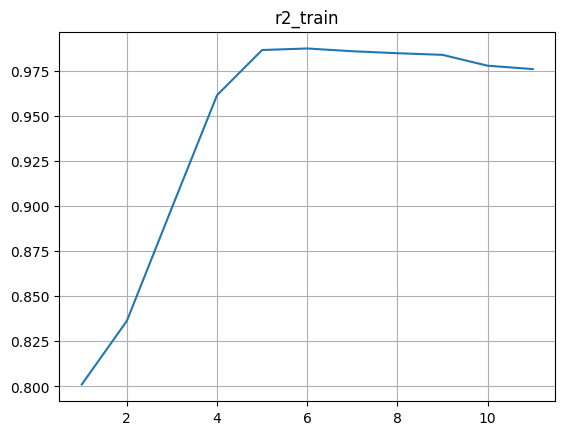

In [15]:
plt.title("r2_train")
plt.plot(orders, r2_bt_train, label='train')
plt.grid()

Mô hình bắt đầu không phù hợp với tập test, đặc biệt bắt đầu từ bậc 2, tệ hơn ở bậc 3 và "đổ vỡ" ở bậc 5, các bậc cao hơn không có kết quả khả quan.

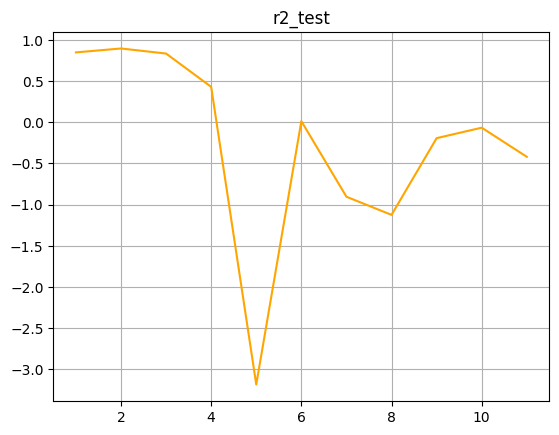

In [16]:
plt.title("r2_test")
plt.plot(orders, r2_bt_test, label='test', color="orange")
plt.grid()

Đặt cả 2 tập trên một sơ đồ: mô hình nhiều bậc cố gắng thỏa mãn (overfitting) tập train và có kết quả phù hợp thậm tệ với tập test.

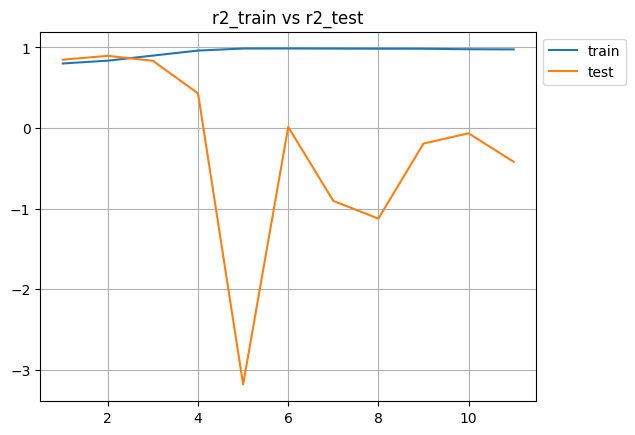

In [17]:
plt.title("r2_train vs r2_test")
plt.plot(orders, r2_bt_train, label='train')
plt.plot(orders, r2_bt_test, label='test')
plt.grid(which='both')
plt.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),
    fancybox=True,
    # shadow=True
)

#### Đánh giá dựa theo MSE

- Khi tăng số bậc, mô hình càng tốt dần cho tập train, sơ đồ tiến về 0, và tốt nhất ở khoảng bậc 5-8, tương tự như sơ đồ R2 đã chỉ ra.

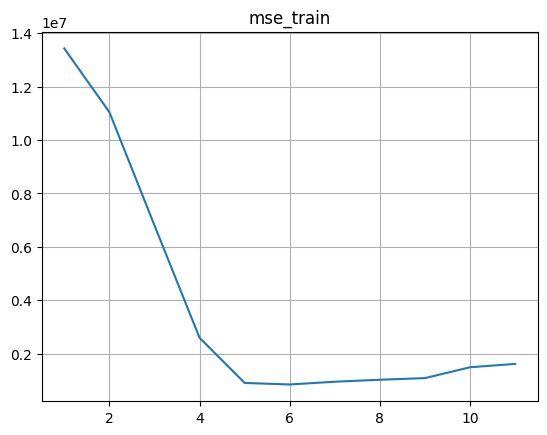

In [18]:
plt.title("mse_train")
plt.plot(orders, mse_bt_train, label='train')
plt.grid()

- Tuy nhiên, so với tập test, mô hình thể hiện sự không phù hợp ngay ở bậc 3, và tạo ra sai số rất lớn ở bậc 5. Các bậc cao hơn không giúp cho mô hình có kết quả tốt hơn với tập test.

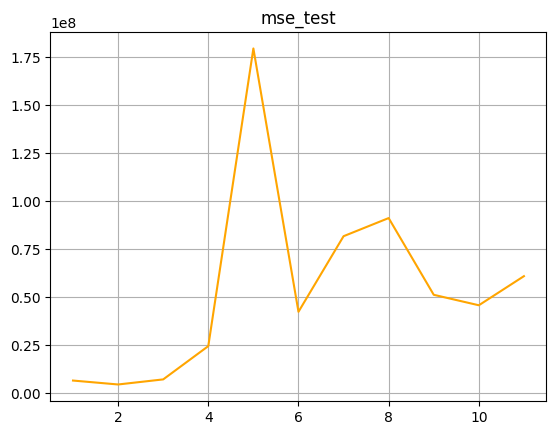

In [19]:
plt.title("mse_test")
plt.plot(orders, mse_bt_test, label='test', color="orange")
plt.grid()

So sánh trực quan cho cả 2 tập train và test trên cùng một sơ đồ cho thấy sự đối lập rất lớn về mức độ phù hợp.

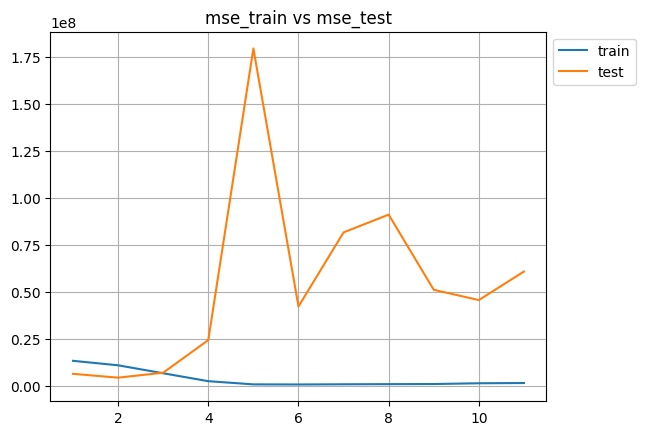

In [20]:
plt.title("mse_train vs mse_test")
plt.plot(orders, mse_bt_train, label='train')
plt.plot(orders, mse_bt_test, label='test')
plt.grid(which='both')
plt.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),
    fancybox=True,
    # shadow=True
)

### Kết luận và đánh giá chung

Như vậy, có thể thấy cả 2 cách đánh giá, $R^2$ và MSE đều cho một góc nhìn chung:

- Mô hình overfitting với tập train khi tăng bậc, đặc biệt từ bậc 3-8.
- Nhưng trong cùng khoảng số bậc này, mô hình không phù hợp (underfitting) với tập test, thậm chí biến động mạnh cho thấy sự KHÔNG phù hợp là rất lớn (đối với tập test).
- Điểm tối ưu nhất cho mô hình là ở bậc 2 khi có sự phù hợp tốt nhất cho cả tập train và tập test.